<a href="https://colab.research.google.com/github/Asuskf/from-nlp-to-agents/blob/tokens/tokens/GenAI_Unit_Economics_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenAI GPT-5.6-Luna: Economic Viability & ROI Analysis
**Model:** `gpt-5.6-luna`

**Context Window:** 1,050,000 tokens | **Max Output:** 128,000 tokens

**Pricing:** $1.00 / 1M Input Tokens | $6.00 / 1M Output Tokens

This notebook models the economic feasibility of an LLM application using OpenAI's GPT-5.6-Luna. It includes:
1. **Microeconomics**: Token-level costs with OpenAI's Prompt Caching mechanics.
2. **Cost Structure**: Fixed Application-to-Application (A2A) infrastructure vs. Variable User Costs.
3. **Financial Metrics**: Break-Even Point (BEP) and Return on Investment (ROI).
4. **Macroeconomics**: Compute cost decay (hardware efficiency) and scaling effects.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '${:,.4f}'.format

## 1. Microeconomics: Unit Economics & Token Costs (GPT-5.6-Luna)

At the micro level, we calculate the cost per query based on OpenAI's $1/$6 per million tokens structure.
We also introduce **Prompt Caching**, a key OpenAI feature where cached input tokens receive a discount (typically ~90% off standard input rates for repeated A2A system prompts).

$$
\text{Cost}_{\text{query}} = (T_{in\_uncached} \times C_{in}) + (T_{in\_cached} \times C_{cache}) + (T_{out} \times C_{out})
$$

In [5]:
class OpenAILunaEconomics:
    def __init__(self,
                 cost_per_1m_in: float = 1.00,
                 cost_per_1m_out: float = 6.00,
                 cache_discount: float = 0.90):
        """
        Initializes OpenAI GPT-5.6-Luna pricing.
        Prices are per 1,000,000 tokens.
        """
        self.cost_per_token_in = cost_per_1m_in / 1_000_000
        self.cost_per_token_out = cost_per_1m_out / 1_000_000
        # Cached inputs are heavily discounted
        self.cost_per_token_cached = self.cost_per_token_in * (1 - cache_discount)

    def calculate_query_cost(self,
                             system_prompt_tokens: int,
                             user_input_tokens: int,
                             avg_tokens_out: int,
                             cache_hit_rate: float = 0.70) -> float:
        """
        Calculates the cost of a single API call, factoring in System Prompts (A2A)
        and whether they hit the prompt cache.
        """
        # System prompts usually hit the cache, user inputs usually don't
        cached_tokens = system_prompt_tokens * cache_hit_rate
        uncached_tokens = (system_prompt_tokens * (1 - cache_hit_rate)) + user_input_tokens

        in_cost = (uncached_tokens * self.cost_per_token_in) + (cached_tokens * self.cost_per_token_cached)
        out_cost = avg_tokens_out * self.cost_per_token_out

        return in_cost + out_cost

    def monthly_variable_cost_per_user(self,
                                       system_tokens: int,
                                       user_tokens: int,
                                       out_tokens: int,
                                       queries_per_day: int,
                                       active_days: int = 20,
                                       cache_hit_rate: float = 0.80) -> float:
        """Calculates the variable LLM cost generated by a single user per month."""
        query_cost = self.calculate_query_cost(system_tokens, user_tokens, out_tokens, cache_hit_rate)
        return query_cost * queries_per_day * active_days

# Instantiate GPT-5.6-Luna Model
luna_model = OpenAILunaEconomics()

# Example: 2000 token system prompt (RAG context), 300 user tokens, 500 output tokens
cost_per_user = luna_model.monthly_variable_cost_per_user(
    system_tokens=2000,
    user_tokens=300,
    out_tokens=500,
    queries_per_day=20,
    cache_hit_rate=0.85 # High cache hit rate for static A2A context
)
print(f"Variable GPT-5.6-Luna Cost per User (Monthly): ${cost_per_user:.4f}")

Variable GPT-5.6-Luna Cost per User (Monthly): $1.5080


## 2. Cost Structure: Fixed (A2A) vs Variable (User) & ROI Projections

We split costs into:
*   **Fixed Costs (A2A)**: Cloud hosting, Vector Databases (Pinecone/Milvus), API Gateways, orchestration overhead.
*   **Variable Costs**: The exact OpenAI API token usage per user.

$$
\text{BEP (Users)} = \frac{\text{Fixed Costs}}{\text{Revenue per User} - \text{Variable Cost per User}}
$$

In [6]:
class FinancialProjections:
    def __init__(self, fixed_monthly_cost: float, customer_revenue_monthly: float):
        self.fixed_monthly_cost = fixed_monthly_cost
        self.customer_revenue_monthly = customer_revenue_monthly

    def break_even_point(self, variable_cost_per_user: float) -> float:
        """Calculates active users needed to cover all fixed and variable costs."""
        contribution_margin = self.customer_revenue_monthly - variable_cost_per_user
        if contribution_margin <= 0:
            raise ValueError("Unviable: Variable OpenAI cost exceeds Revenue per user.")
        return self.fixed_monthly_cost / contribution_margin

    def quarterly_roi_projection(self,
                                 variable_cost_per_user: float,
                                 initial_investment: float,
                                 user_growth_trajectory: list) -> pd.DataFrame:
        """Projects Quarterly Revenue, Costs, and Cumulative ROI."""
        quarters = len(user_growth_trajectory)

        fixed_cost_q = self.fixed_monthly_cost * 3
        revenue_per_user_q = self.customer_revenue_monthly * 3
        var_cost_per_user_q = variable_cost_per_user * 3

        data = {
            'Quarter': [f"Q{i+1}" for i in range(quarters)],
            'Avg_Active_Users': user_growth_trajectory,
            'Revenue': [u * revenue_per_user_q for u in user_growth_trajectory],
            'Fixed_A2A_Costs': [fixed_cost_q] * quarters,
            'Variable_OpenAI_Costs': [u * var_cost_per_user_q for u in user_growth_trajectory],
        }

        df = pd.DataFrame(data)
        df['Total_Costs'] = df['Fixed_A2A_Costs'] + df['Variable_OpenAI_Costs']
        df['Net_Income'] = df['Revenue'] - df['Total_Costs']
        df['Cumulative_Net_Income'] = df['Net_Income'].cumsum()
        df['Cumulative_ROI_%'] = (df['Cumulative_Net_Income'] / initial_investment) * 100

        return df

# Assuming $3,500/mo in A2A infra and charging $15.00/mo per user for an AI Agent
finances = FinancialProjections(fixed_monthly_cost=3500, customer_revenue_monthly=15.00)

bep_users = finances.break_even_point(cost_per_user)
print(f"Break-Even Point: {np.ceil(bep_users)} active users")

# Projecting over 6 quarters with an initial build investment of $40,000
user_projection = [300, 800, 1500, 3000, 5000, 8000]
df_projections = finances.quarterly_roi_projection(
    variable_cost_per_user=cost_per_user,
    initial_investment=40000,
    user_growth_trajectory=user_projection
)

# Fix formatting for display
pd.options.display.float_format = '${:,.2f}'.format
display(df_projections)

Break-Even Point: 260.0 active users


,Quarter,Avg_Active_Users,Revenue,Fixed_A2A_Costs,Variable_OpenAI_Costs,Total_Costs,Net_Income,Cumulative_Net_Income,Cumulative_ROI_%
0,Q1,300,"$13,500.00",10500,"$1,357.20","$11,857.20","$1,642.80","$1,642.80",$4.11
1,Q2,800,"$36,000.00",10500,"$3,619.20","$14,119.20","$21,880.80","$23,523.60",$58.81
2,Q3,1500,"$67,500.00",10500,"$6,786.00","$17,286.00","$50,214.00","$73,737.60",$184.34
3,Q4,3000,"$135,000.00",10500,"$13,572.00","$24,072.00","$110,928.00","$184,665.60",$461.66
4,Q5,5000,"$225,000.00",10500,"$22,620.00","$33,120.00","$191,880.00","$376,545.60",$941.36
5,Q6,8000,"$360,000.00",10500,"$36,192.00","$46,692.00","$313,308.00","$689,853.60","$1,724.63"


## 3. Macroeconomics: OpenAI API Cost Decay & Scaling

Historically, OpenAI reduces API pricing for its models over time as hardware scales and inference algorithms improve (e.g., from GPT-3.5 to GPT-4o-mini to GPT-5.6-Luna).
We model this macroeconomic reality using a quarterly **Cost Decay Rate**.

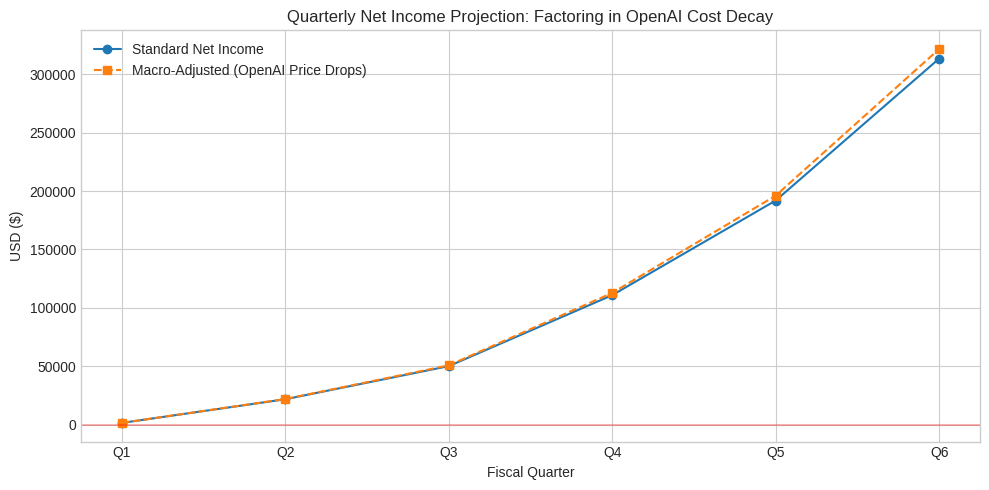

In [7]:
def openai_macro_simulation(df: pd.DataFrame,
                            api_cost_decay_rate: float = 0.05) -> pd.DataFrame:
    """
    Simulates macroeconomic impacts:
    - api_cost_decay_rate: Expected % reduction in OpenAI API costs per quarter
      (Moore's law analog for model inference efficiency).
    """
    df_macro = df.copy()

    # Apply compounding decay to variable OpenAI costs
    decay_multipliers = [(1 - api_cost_decay_rate) ** i for i in range(len(df_macro))]
    df_macro['Macro_OpenAI_Costs'] = df_macro['Variable_OpenAI_Costs'] * decay_multipliers

    # Recalculate Net Income
    df_macro['Macro_Net_Income'] = df_macro['Revenue'] - (df_macro['Fixed_A2A_Costs'] + df_macro['Macro_OpenAI_Costs'])

    return df_macro

# Simulating a 5% drop in API costs quarter-over-quarter
df_macro_adj = openai_macro_simulation(df_projections, api_cost_decay_rate=0.05)

# Visualizing the difference
plt.figure(figsize=(10, 5))
plt.plot(df_macro_adj['Quarter'], df_macro_adj['Net_Income'], label='Standard Net Income', marker='o')
plt.plot(df_macro_adj['Quarter'], df_macro_adj['Macro_Net_Income'], label='Macro-Adjusted (OpenAI Price Drops)', marker='s', linestyle='--')

plt.title('Quarterly Net Income Projection: Factoring in OpenAI Cost Decay')
plt.xlabel('Fiscal Quarter')
plt.ylabel('USD ($)')
plt.axhline(0, color='red', linestyle='-', alpha=0.3) # Break-even line
plt.legend()
plt.tight_layout()
plt.show()

## 4. Advanced Break-Even Analysis: Volume, Pricing, and Target Costing

The Break-Even Point (BEP) is dynamic. Depending on the go-to-market strategy, we can solve for different variables:

**1. Required Volume (How much to sell):**
$$
\text{Volume} = \frac{\text{Fixed Costs}}{\text{Price per User} - \text{Variable Cost per User}}
$$

**2. Required Price (Minimum viable price):**
$$
\text{Price} = \frac{\text{Fixed Costs}}{\text{Target Users}} + \text{Variable Cost per User}
$$

**3. Target Variable Cost (Maximum allowable LLM cost):**
$$
\text{Max Cost} = \text{Price} - \frac{\text{Fixed Costs}}{\text{Target Users}}
$$

1. Volume needed: 280.0 users to break even at $15/month.
2. Minimum Price needed: $20.00/month to break even with 200 users.
3. Max Allowable LLM Cost: $3.00/user. (If OpenAI costs > $3.00, we lose money).


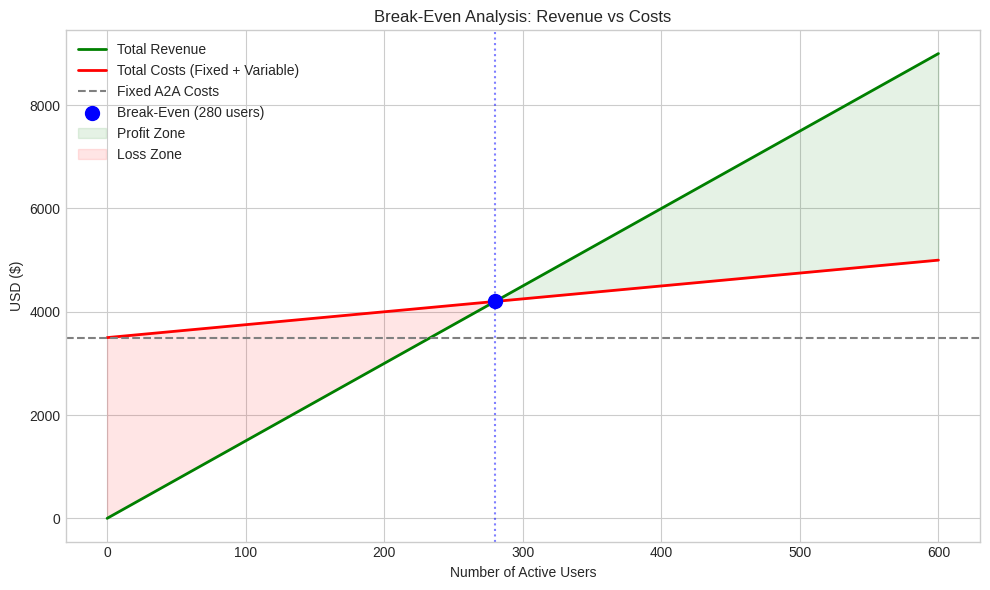

In [8]:
class AdvancedBreakEven:
    def __init__(self, fixed_monthly_cost: float):
        """
        Focuses on the triad of Break-Even: Volume, Price, and Variable Cost.
        """
        self.fixed_monthly_cost = fixed_monthly_cost

    def required_volume(self, price_per_user: float, variable_cost_per_user: float) -> float:
        """Calculates how many users are needed to break even."""
        margin = price_per_user - variable_cost_per_user
        if margin <= 0:
            return float('inf') # Impossible to break even
        return self.fixed_monthly_cost / margin

    def required_price(self, target_users: int, variable_cost_per_user: float) -> float:
        """Calculates the minimum subscription price needed given a target user base."""
        return (self.fixed_monthly_cost / target_users) + variable_cost_per_user

    def target_variable_cost(self, price_per_user: float, target_users: int) -> float:
        """Calculates the maximum allowable LLM cost per user to avoid losses."""
        return price_per_user - (self.fixed_monthly_cost / target_users)

    def plot_break_even_chart(self, price_per_user: float, variable_cost_per_user: float, max_users: int):
        """Generates a classic Break-Even chart (Total Revenue vs Total Costs)."""
        users = np.linspace(0, max_users, 100)

        revenue = users * price_per_user
        total_costs = self.fixed_monthly_cost + (users * variable_cost_per_user)

        bep_users = self.required_volume(price_per_user, variable_cost_per_user)

        plt.figure(figsize=(10, 6))
        plt.plot(users, revenue, label='Total Revenue', color='green', linewidth=2)
        plt.plot(users, total_costs, label='Total Costs (Fixed + Variable)', color='red', linewidth=2)
        plt.axhline(self.fixed_monthly_cost, color='gray', linestyle='--', label='Fixed A2A Costs')

        if bep_users <= max_users:
            bep_revenue = bep_users * price_per_user
            plt.scatter(bep_users, bep_revenue, color='blue', s=100, zorder=5, label=f'Break-Even ({int(bep_users)} users)')
            plt.axvline(bep_users, color='blue', linestyle=':', alpha=0.5)

        plt.title('Break-Even Analysis: Revenue vs Costs')
        plt.xlabel('Number of Active Users')
        plt.ylabel('USD ($)')
        plt.fill_between(users, revenue, total_costs, where=(revenue > total_costs), interpolate=True, color='green', alpha=0.1, label='Profit Zone')
        plt.fill_between(users, revenue, total_costs, where=(revenue <= total_costs), interpolate=True, color='red', alpha=0.1, label='Loss Zone')

        plt.legend()
        plt.tight_layout()
        plt.show()

# --- Execution Example ---

# Scenario: $3,500 monthly fixed infrastructure
be_analysis = AdvancedBreakEven(fixed_monthly_cost=3500)

# We know from Cell 4 that our GPT-5.6-Luna cost per user is approx $2.50
# If we plan to charge $15.00:
bep_vol = be_analysis.required_volume(price_per_user=15.00, variable_cost_per_user=2.50)
print(f"1. Volume needed: {np.ceil(bep_vol)} users to break even at $15/month.")

# If we only have 200 Beta users, what is the minimum price we must charge?
req_price = be_analysis.required_price(target_users=200, variable_cost_per_user=2.50)
print(f"2. Minimum Price needed: ${req_price:.2f}/month to break even with 200 users.")

# If the market only accepts a $10 price, and we have 500 users, what is our token budget?
max_cost = be_analysis.target_variable_cost(price_per_user=10.00, target_users=500)
print(f"3. Max Allowable LLM Cost: ${max_cost:.2f}/user. (If OpenAI costs > ${max_cost:.2f}, we lose money).")

# Plotting the scenario
be_analysis.plot_break_even_chart(price_per_user=15.00, variable_cost_per_user=2.50, max_users=600)